In [1]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
import emcee
import h5py
import corner
import matplotlib.pyplot as plt
import corner
import VBMicrolensing
VBM = VBMicrolensing.VBMicrolensing()
import tqdm
import math
import sys
import multiprocessing
sys.path.append("/moao38_7/nunota/gapmoe/src/gapmoe/")
from gapmoe import gapmoe
import EarthMotion
import parametrics
JD0 = 2450000
from emcee.autocorr import integrated_time

import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
from matplotlib.patches import Patch
import arviz as az

import logging
logging.getLogger("emcee.autocorr").setLevel(logging.ERROR)

from matplotlib.lines import Line2D

tref = 10063.874
coords = "17:57:38.03 -28:38:28.53"

VBM.t0_par = tref+JD0
VBM.parallaxsystem = 1
VBM.SetObjectCoordinates(coords)

RA_str,Dec_str = "17:57:38.03","-28:38:28.53"
RA_deg = EarthMotion.hms_string_to_degrees(RA_str)
Dec_deg = EarthMotion.dms_string_to_degrees(Dec_str)
vEarth = EarthMotion.calc_vEarth(tref,RA_deg,Dec_deg)

gapmoe_model = gapmoe(RA_deg,Dec_deg)
gapmoe_model.set_data()

In [2]:
from matplotlib import rcParams
rcParams["font.size"] = 15
rcParams["axes.linewidth"] = 3
rcParams['xtick.top'] = True
rcParams['ytick.right'] = True
rcParams['xtick.direction'] = 'in'
rcParams['ytick.direction'] = 'in'
rcParams['xtick.major.size'] = 10
rcParams['xtick.major.width'] = 1.5
rcParams['xtick.minor.size'] = 5
rcParams['xtick.minor.width'] = 1.5
rcParams['ytick.major.size'] = 10
rcParams['ytick.major.width'] = 1.5
rcParams['ytick.minor.size'] = 5
rcParams['ytick.minor.width'] = 1.5


mpl.rc('font', **{'family': 'serif', 'serif': ['Liberation Serif', 'DejaVu Serif']})
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 15,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "0.3",
    "axes.linewidth": 1.4,
    "grid.alpha": 0.25,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

In [3]:
def calc_ln_prior_kep(theta, thS, vEarth):
    t0, u0, q, ML, DL, DS, murel_N_hel, murel_E_hel,orbital_radi, e, cos_i, Om_NE, om, nu = parametrics.lightcurve_to_physical_kepler(theta, thS, vEarth)

    mu_abs = jnp.sqrt(murel_E_hel**2 + murel_N_hel**2)
    mu_phi = jnp.arctan2(murel_E_hel, murel_N_hel)
    DL *= 1e3
    DS *= 1e3

    if not (10000 <= t0 <= 11000):
        return -np.inf
    if not (-5 <= u0 <= 5):
        return -np.inf
    if not (1e-5 <= q <= 1.0):
        return -np.inf
    if not (0 <= e <= 1.0):
        return -np.inf
    if not (-np.pi <= Om_NE <= np.pi):
        return -np.inf
    if not (-np.pi <= om <= np.pi):
        return -np.inf
    if not (-np.pi <= nu <= np.pi):
        return -np.inf
    if not (0 <= orbital_radi <= 1e4):
        return -np.inf

    if not (gapmoe_model.M_MIN <= ML <= gapmoe_model.M_MAX):
        return -np.inf
    if not (gapmoe_model.DL_MIN <= DL < gapmoe_model.DL_MAX):
        return -np.inf
    if not (gapmoe_model.DS_MIN <= DS < gapmoe_model.DS_MAX):
        return -np.inf
    if DL >= DS:
        return -np.inf
    if not (gapmoe_model.MU_MIN <= mu_abs < gapmoe_model.MU_MAX):
        return -np.inf

    return gapmoe_model.log_galactic_prior(ML, DL, DS, mu_abs, mu_phi) - np.log(mu_abs) #jacobian for (muN, muE) -> (mu,phi)

In [4]:
import os
import tempfile
import shutil
def read_chain(path, burnin, thin, flat=True):
    tmpdir = tempfile.mkdtemp()
    tmp_path = os.path.join(tmpdir, "chain_copy.h5")
    shutil.copy2(path, tmp_path)

    try:
        sampler = emcee.backends.HDFBackend(tmp_path, read_only=True)
        chain = sampler.get_chain(flat=flat, discard=burnin, thin=thin)
        blob = sampler.get_blobs(flat=flat, discard=burnin, thin=thin)
        lnprob = sampler.get_log_prob(flat=flat, discard=burnin, thin=thin)
    finally:
        try:
            os.remove(tmp_path)
            os.rmdir(tmpdir)
        except Exception:
            pass
    print(chain.shape)

    return chain, blob, lnprob

In [5]:
# kep_gap_chain_01,kep_gap_blob_01 = read_chain("../test_result/rogue1/backend/rerun_simu_05_kepler_01.h5",0,1,flat=False)
# kep_wo_chain_01,kep_wo_blob_01 = read_chain("../test_result/rogue1/backend/rerun_wo_gap_simu_05_kepler_01.h5",0,1,flat=False)


In [6]:
# kep_gap_chain_01_add, kep_gap_blob_01_add = read_chain("../test_result/rogue1/backend/rerun_simu_05_kepler_02.h5",40000,1,flat=False)
# kep_wo_chain_01_add,kep_wo_blob_01_add = read_chain("../test_result/rogue1/backend/rerun_wo_gap_simu_05_kepler_02.h5",50000,1,flat=False)



In [7]:
# # kep_gap_chain_01_all = np.concatenate([kep_gap_chain_01, kep_gap_chain_01_add], axis=0)
# # kep_wo_chain_01_all  = np.concatenate([kep_wo_chain_01,  kep_wo_chain_01_add],  axis=0)

# # kep_gap_blob_01_all = np.concatenate([kep_gap_blob_01, kep_gap_blob_01_add], axis=0)
# # kep_wo_blob_01_all  = np.concatenate([kep_wo_blob_01,  kep_wo_blob_01_add],  axis=0)

# kep_gap_chain_01_all = kep_gap_chain_01_add
# kep_wo_chain_01_all  = kep_wo_chain_01_add

# kep_gap_blob_01_all = kep_gap_blob_01_add
# kep_wo_blob_01_all  = kep_wo_blob_01_add

In [8]:
kep_gap_chain_02, kep_gap_blob_02,kep_gap_prob_02  = read_chain("../test_result/rogue1/backend/rerun_simu_05_kepler_02.h5",50000,1,flat=False)
kep_wo_chain_02,kep_wo_blob_02, kep_wo_prob_02 = read_chain("../test_result/rogue1/backend/rerun_wo_gap_simu_05_kepler_02.h5",40000,1,flat=False)

kep_gap_chain_03, kep_gap_blob_03,kep_gap_prob_03  = read_chain("../test_result/rogue1/backend/rerun_simu_05_kepler_03.h5",50,1,flat=False)
kep_wo_chain_03,kep_wo_blob_03, kep_wo_prob_03 = read_chain("../test_result/rogue1/backend/rerun_wo_gap_simu_05_kepler_03.h5",50,1,flat=False)

kep_gap_chain_04, kep_gap_blob_04,kep_gap_prob_04  = read_chain("../test_result/rogue1/backend/rerun_simu_05_kepler_04.h5",50,1,flat=False)
kep_wo_chain_04,kep_wo_blob_04, kep_wo_prob_04 = read_chain("../test_result/rogue1/backend/rerun_wo_gap_simu_05_kepler_04.h5",50,1,flat=False)

kep_gap_chain_05, kep_gap_blob_05,kep_gap_prob_05  = read_chain("../test_result/rogue1/backend/rerun_simu_05_kepler_05.h5",50,1,flat=False)
kep_wo_chain_05,kep_wo_blob_05, kep_wo_prob_05 = read_chain("../test_result/rogue1/backend/rerun_wo_gap_simu_05_kepler_05.h5",50,1,flat=False)

kep_gap_chain_06, kep_gap_blob_06,kep_gap_prob_06  = read_chain("../test_result/rogue1/backend/rerun_simu_05_kepler_06.h5",50,1,flat=False)
kep_wo_chain_06,kep_wo_blob_06, kep_wo_prob_06 = read_chain("../test_result/rogue1/backend/rerun_wo_gap_simu_05_kepler_06.h5",50,1,flat=False)

# ==== chain ====
kep_gap_chain = np.concatenate(
    [kep_gap_chain_02, kep_gap_chain_03, kep_gap_chain_04, kep_gap_chain_05, kep_gap_chain_06],
    axis=0
)
kep_wo_chain = np.concatenate(
    [kep_wo_chain_02, kep_wo_chain_03, kep_wo_chain_04, kep_wo_chain_05, kep_wo_chain_06],
    axis=0
)

# ==== blob ====
kep_gap_blob = np.concatenate(
    [kep_gap_blob_02, kep_gap_blob_03, kep_gap_blob_04, kep_gap_blob_05, kep_gap_blob_06],
    axis=0
)
kep_wo_blob = np.concatenate(
    [kep_wo_blob_02, kep_wo_blob_03, kep_wo_blob_04, kep_wo_blob_05, kep_wo_blob_06],
    axis=0
)

# ==== prob ====
kep_gap_prob = np.concatenate(
    [kep_gap_prob_02, kep_gap_prob_03, kep_gap_prob_04, kep_gap_prob_05, kep_gap_prob_06],
    axis=0
)
kep_wo_prob = np.concatenate(
    [kep_wo_prob_02, kep_wo_prob_03, kep_wo_prob_04, kep_wo_prob_05, kep_wo_prob_06],
    axis=0
)


(80126, 28, 14)
(98571, 28, 14)
(17322, 28, 14)
(18566, 28, 14)
(9477, 28, 14)
(9331, 28, 14)
(8588, 28, 14)
(10243, 28, 14)
(8770, 28, 14)
(9582, 28, 14)


In [9]:
def calc_tau(arr):
    taus = []
    for pi in range(arr.shape[2]):
        tau_walkers = []
        for w in range(arr.shape[1]):
            chain = arr[:, w, pi]
            tau = emcee.autocorr.integrated_time(chain[:, None], quiet=True)
            tau_walkers.append(tau.item())
        mean_tau = np.min(tau_walkers)
        taus.append(mean_tau)
        print(f"param[{pi}] mean τ_int over {arr.shape[1]} walkers = {mean_tau:.2f}")

    return max(taus)
    
def tau_progress(arr, step=10000):
    nsteps, nwalkers, nparams = arr.shape
    steps = []
    tau_matrix = []

    for n in range(step, nsteps+1, step):
        taus = []
        for pi in range(nparams):
            tau_walkers = []
            for w in range(nwalkers):
                chain = arr[:n, w, pi]
                tau = emcee.autocorr.integrated_time(chain[:, None], quiet=True)
                tau_walkers.append(tau.item())
            mean_tau = np.min(tau_walkers)
            taus.append(mean_tau)
        steps.append(n)
        tau_matrix.append(taus)

    return np.array(steps), np.array(tau_matrix)


In [12]:
tau_gap_01 = calc_tau(kep_gap_chain)
tau_wo_01 = calc_tau(kep_wo_chain)

param[0] mean τ_int over 28 walkers = 1194.53
param[1] mean τ_int over 28 walkers = 1857.33
param[2] mean τ_int over 28 walkers = 1810.27
param[3] mean τ_int over 28 walkers = 1177.31
param[4] mean τ_int over 28 walkers = 1804.57
param[5] mean τ_int over 28 walkers = 1448.93
param[6] mean τ_int over 28 walkers = 2204.59
param[7] mean τ_int over 28 walkers = 2094.07
param[8] mean τ_int over 28 walkers = 2050.59
param[9] mean τ_int over 28 walkers = 1676.39
param[10] mean τ_int over 28 walkers = 1469.79
param[11] mean τ_int over 28 walkers = 3059.72
param[12] mean τ_int over 28 walkers = 2084.33
param[13] mean τ_int over 28 walkers = 3036.34
param[0] mean τ_int over 28 walkers = 1771.60
param[1] mean τ_int over 28 walkers = 1240.95
param[2] mean τ_int over 28 walkers = 1368.08
param[3] mean τ_int over 28 walkers = 1594.48
param[4] mean τ_int over 28 walkers = 1706.51
param[5] mean τ_int over 28 walkers = 1497.41
param[6] mean τ_int over 28 walkers = 1389.48
param[7] mean τ_int over 28 wa

In [13]:
steps_gap, tau_mat_gap_01 = tau_progress(kep_gap_chain, step=10000)
steps_wo, tau_mat_wo_01 = tau_progress(kep_wo_chain, step=10000)


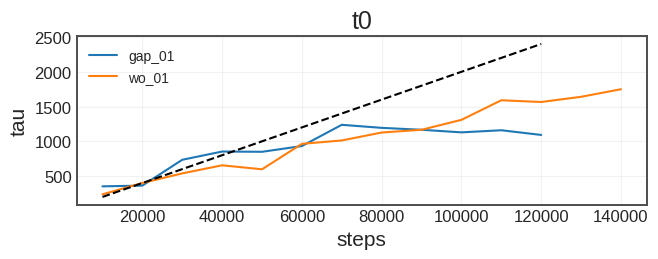

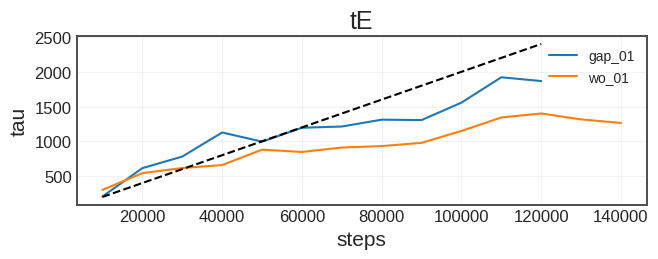

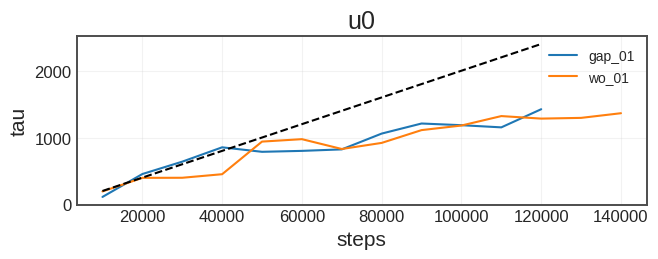

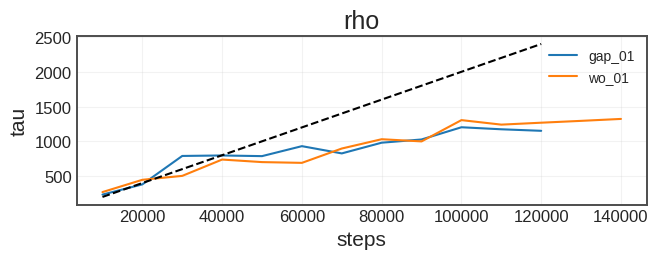

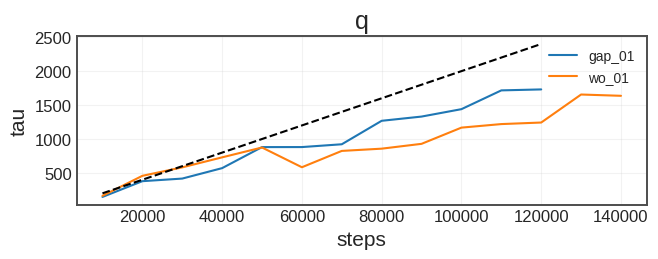

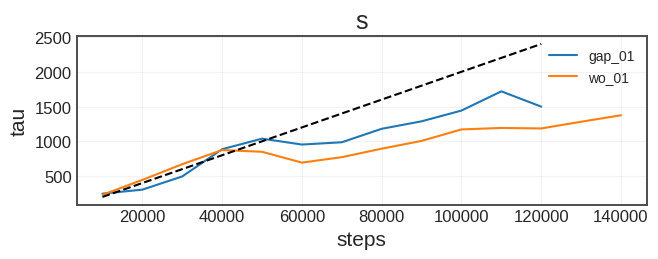

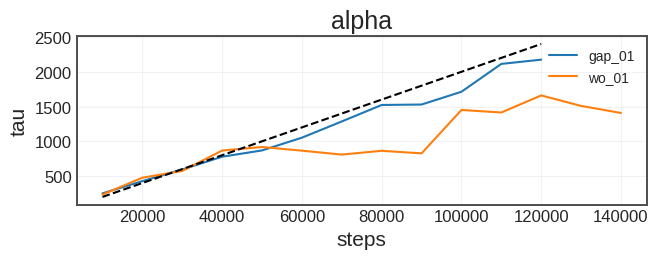

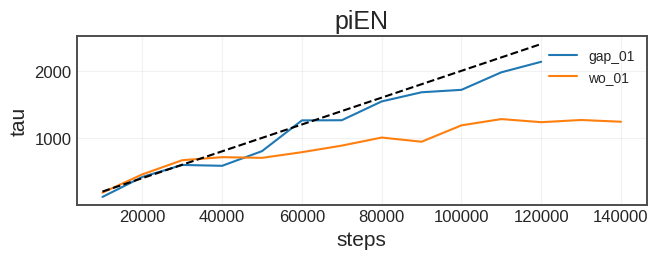

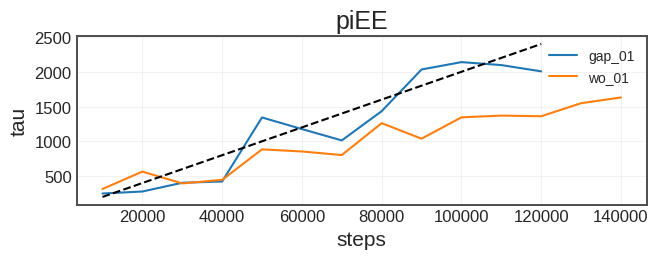

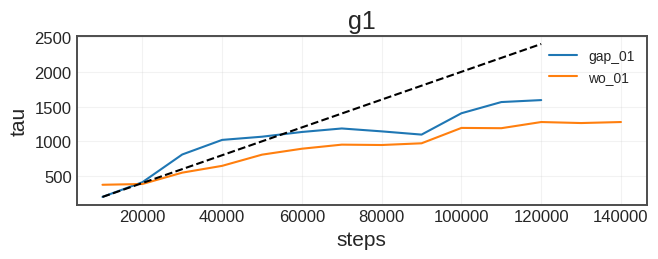

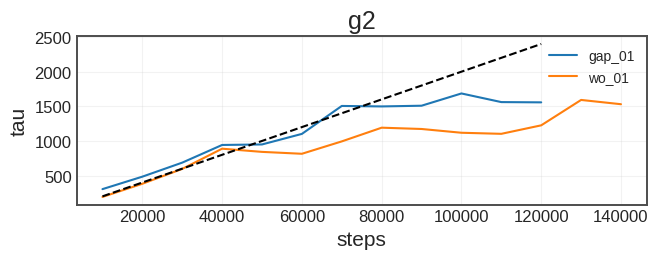

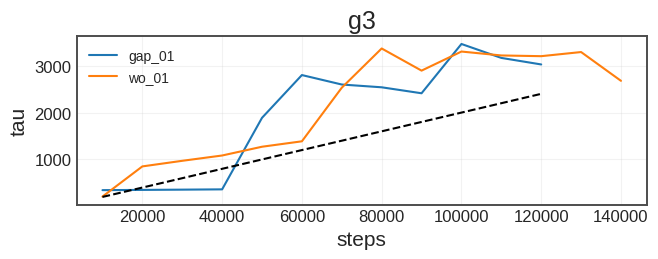

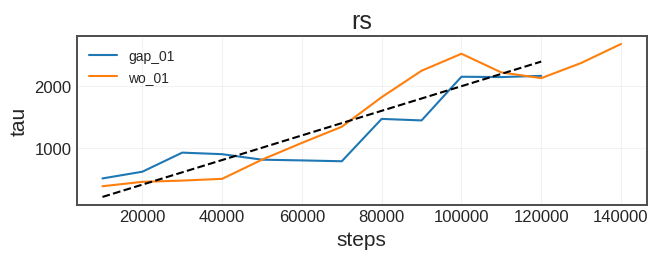

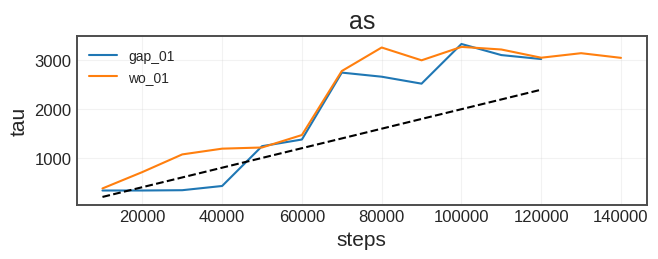

In [14]:
params = ["t0","tE","u0","rho","q","s","alpha","piEN","piEE","g1","g2","g3","rs","as"]
for i in range(tau_mat_gap_01.shape[1]):
    plt.figure(figsize=(7,3))
    plt.plot(steps_gap, tau_mat_gap_01[:,i], label="gap_01")
    plt.plot(steps_wo, tau_mat_wo_01[:,i], label="wo_01")
    
    plt.plot(steps_gap, steps_gap/50, "k--")
    
    plt.xlabel("steps")
    plt.ylabel("tau")
    plt.title(f"{params[i]}")
    plt.legend(fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

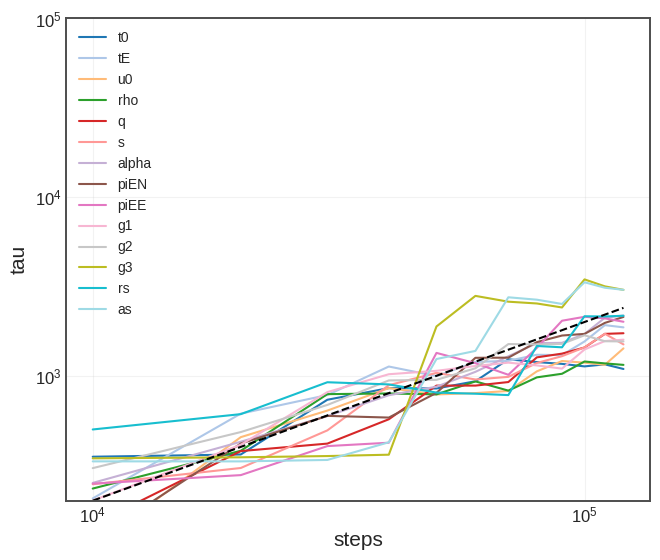

In [15]:
params = ["t0","tE","u0","rho","q","s","alpha","piEN","piEE","g1","g2","g3","rs","as"]
colors = plt.cm.tab20(np.linspace(0, 1, len(params)))  # 14 色生成


plt.figure(figsize=(7,6))

for i in range(tau_mat_gap_01.shape[1]):
    plt.plot(steps_gap, tau_mat_gap_01[:,i], color=colors[i], label=params[i])

plt.plot(steps_gap, steps_gap/50, "k--")

plt.xscale("log")
plt.yscale("log")
plt.ylim(2e2,1e5)
plt.xlabel("steps")
plt.ylabel("tau")
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

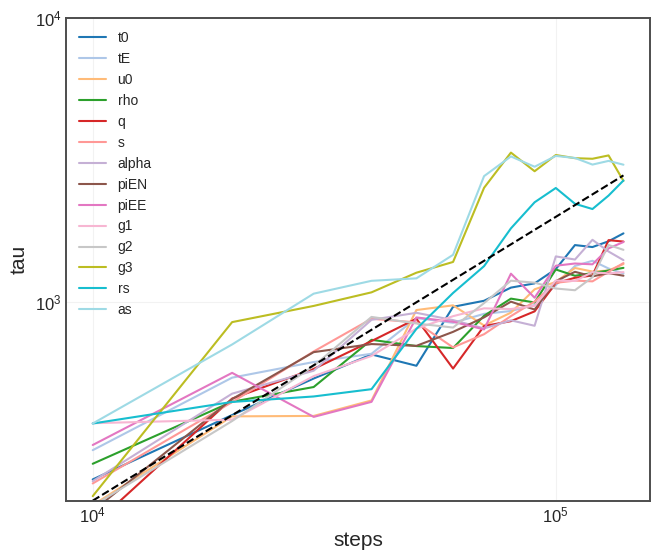

In [16]:
params = ["t0","tE","u0","rho","q","s","alpha","piEN","piEE","g1","g2","g3","rs","as"]
colors = plt.cm.tab20(np.linspace(0, 1, len(params)))  # 14 色生成


plt.figure(figsize=(7,6))

for i in range(tau_mat_wo_01.shape[1]):
    plt.plot(steps_wo, tau_mat_wo_01[:,i], color=colors[i], label=params[i])

plt.plot(steps_wo, steps_wo/50, "k--")

plt.xscale("log")
plt.yscale("log")
plt.ylim(2e2,1e4)
plt.xlabel("steps")
plt.ylabel("tau")
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
kep_gap_chain_01_thinned =  kep_gap_chain_01_all[1000:].reshape(-1, 14)[::int(tau_gap_01)+1]
kep_wo_chain_01_thinned =  kep_wo_chain_01_all[1000:].reshape(-1, 14)[::int(tau_wo_01)+1]

kep_gap_blob_01_thinned =  kep_gap_blob_01_all[1000:].reshape(-1)[::int(tau_gap_01)+1]
kep_wo_blob_01_thinned =  kep_wo_blob_01_all[1000:].reshape(-1)[::int(tau_wo_01)+1]

In [ ]:
vmap_kep = jax.vmap(
    lambda theta, thS: parametrics.lightcurve_to_physical_kepler(theta, thS, vEarth),
    in_axes=(0, 0)
)

vmap_det_kep = jax.vmap(
    lambda theta, thS: parametrics.calc_ln_det_jacobian_kepler(theta, thS, vEarth),
    in_axes=(0, 0)
)

kep_gap_phys_01 = np.array(vmap_kep(kep_gap_chain_01_thinned,kep_gap_blob_01_thinned))
kep_wo_phys_01 = np.array(vmap_kep(kep_wo_chain_01_thinned, kep_wo_blob_01_thinned))
kep_wo_det_01 = np.array(vmap_det_kep(kep_wo_chain_01_thinned, kep_wo_blob_01_thinned))
kep_wo_gal_01 = np.array(list(map(
    lambda args: calc_ln_prior_kep(args[0], args[1], vEarth),
    zip(kep_wo_chain_01_thinned, kep_wo_blob_01_thinned)
)))

weight_kep_01 = np.exp((kep_wo_det_01 + kep_wo_gal_01) - np.max(kep_wo_det_01 + kep_wo_gal_01))
weight_kep_01 /= np.sum(weight_kep_01)

In [ ]:
Neff_gap_01 = kep_gap_chain_01_thinned.shape[0]
Neff_wo_01_unw = kep_wo_chain_01_thinned.shape[0]

Neff_wo_01 = (np.sum(weight_kep_01)**2) / np.sum(weight_kep_01**2)

In [ ]:
print(Neff_gap_01)
print(Neff_wo_01_unw)

print(Neff_wo_01)


In [ ]:
tau_gap_01*50